# Notebook 05 — Analysis & Plots

Loads all results from Notebooks 02–04 and produces:

| Output | Description |
|---|---|
| **Table 1** | Method comparison — ε_upper, ε_lower, runtime across all models |
| **Table 2** | Tightness vs ground truth (concolic vs LP-exact on SmallMLP) |
| **Figure 1** | Bound distribution violin plots per method per model |
| **Figure 2** | Runtime vs network size (scalability curve) |
| **Figure 3** | ε_upper vs ε_lower scatter — bound gap visualisation |
| **Figure 4** | Heuristic comparison — nearest-boundary vs random |

All figures are saved as `.pdf` (paper-ready) and `.png` (preview).

**Requires:** all result files from Notebooks 02, 03, 04

**Outputs saved to:**
```
results/figures/
results/tables/
```

## 0 — Install dependencies

In [1]:
import subprocess, sys
for pkg in ['matplotlib', 'numpy', 'scipy']:
    subprocess.run([sys.executable, '-m', 'pip', 'install', pkg, '--quiet'], check=False)
import matplotlib
print(f'matplotlib: {matplotlib.__version__}')

matplotlib: 3.10.9


## 1 — Imports & configuration

In [2]:
import sys, os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from pathlib import Path

REPO_ROOT   = Path(os.getcwd())
sys.path.insert(0, str(REPO_ROOT))

from utils.metrics import load_results, tightness_score, save_results

RESULTS_DIR = REPO_ROOT / 'results'
FIGURES_DIR = RESULTS_DIR / 'figures'
TABLES_DIR  = RESULTS_DIR / 'tables'
for d in [FIGURES_DIR, TABLES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ── plot style ────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'font.family'      : 'serif',
    'font.size'        : 11,
    'axes.titlesize'   : 12,
    'axes.labelsize'   : 11,
    'xtick.labelsize'  : 10,
    'ytick.labelsize'  : 10,
    'legend.fontsize'  : 10,
    'figure.dpi'       : 150,
    'savefig.dpi'      : 300,
    'savefig.bbox'     : 'tight',
    'axes.grid'        : True,
    'grid.alpha'       : 0.3,
})

# colour palette — accessible, print-friendly
COLORS = {
    'fgsm'     : '#E69F00',
    'pgd'      : '#56B4E9',
    'concolic' : '#009E73',
    'exact'    : '#CC79A7',
}

MODEL_LABELS = {
    'small_mnist'  : 'Small\n(128 neurons)',
    'medium_mnist' : 'Medium\n(768 neurons)',
    'large_cifar'  : 'Large\n(2048 neurons)',
}

def savefig(name):
    for ext in ['pdf', 'png']:
        path = FIGURES_DIR / f'{name}.{ext}'
        plt.savefig(path)
    print(f'  Saved → {name}.pdf / .png')

print('Config ready.')

Config ready.


## 2 — Load all results

In [3]:
print('Loading results...')

# baselines
bl_small  = load_results(str(RESULTS_DIR / 'baselines_small_mnist.json'))
bl_medium = load_results(str(RESULTS_DIR / 'baselines_medium_mnist.json'))
bl_large  = load_results(str(RESULTS_DIR / 'baselines_large_cifar.json'))

# concolic
co_small  = load_results(str(RESULTS_DIR / 'concolic_small_mnist.json'))
co_medium = load_results(str(RESULTS_DIR / 'concolic_medium_mnist.json'))
co_large  = load_results(str(RESULTS_DIR / 'concolic_large_cifar.json'))

# exact verification
exact     = load_results(str(RESULTS_DIR / 'marabou_small_mnist.json'))

# scalability
scalability = load_results(str(RESULTS_DIR / 'marabou_scalability.json'))

# heuristic sensitivity
heuristic = load_results(str(RESULTS_DIR / 'heuristic_sensitivity.json'))

print('All result files loaded.')

# ── convenience arrays ────────────────────────────────────────────────────────
models = ['small_mnist', 'medium_mnist', 'large_cifar']

def get_uppers(result, method):
    return np.array([r['eps_upper'] for r in result[method]['per_sample']])

def get_concolic_field(result, field):
    return np.array([r[field] for r in result['per_sample']])

# per-sample arrays
data = {
    'small_mnist': {
        'fgsm'     : get_uppers(bl_small, 'fgsm'),
        'pgd'      : get_uppers(bl_small, 'pgd'),
        'concolic_upper': get_concolic_field(co_small, 'eps_upper'),
        'concolic_lower': get_concolic_field(co_small, 'eps_lower'),
        'exact'    : np.array([r['eps_star'] for r in exact['per_sample']
                               if not r['timed_out']]),
    },
    'medium_mnist': {
        'fgsm'          : get_uppers(bl_medium, 'fgsm'),
        'pgd'           : get_uppers(bl_medium, 'pgd'),
        'concolic_upper': get_concolic_field(co_medium, 'eps_upper'),
        'concolic_lower': get_concolic_field(co_medium, 'eps_lower'),
        'exact'         : np.array([]),
    },
    'large_cifar': {
        'fgsm'          : get_uppers(bl_large, 'fgsm'),
        'pgd'           : get_uppers(bl_large, 'pgd'),
        'concolic_upper': get_concolic_field(co_large, 'eps_upper'),
        'concolic_lower': get_concolic_field(co_large, 'eps_lower'),
        'exact'         : np.array([]),
    },
}
print('Data arrays prepared.')

Loading results...
  Loaded results ← D:\concolic_exploration\results\baselines_small_mnist.json
  Loaded results ← D:\concolic_exploration\results\baselines_medium_mnist.json
  Loaded results ← D:\concolic_exploration\results\baselines_large_cifar.json
  Loaded results ← D:\concolic_exploration\results\concolic_small_mnist.json
  Loaded results ← D:\concolic_exploration\results\concolic_medium_mnist.json
  Loaded results ← D:\concolic_exploration\results\concolic_large_cifar.json
  Loaded results ← D:\concolic_exploration\results\marabou_small_mnist.json
  Loaded results ← D:\concolic_exploration\results\marabou_scalability.json
  Loaded results ← D:\concolic_exploration\results\heuristic_sensitivity.json
All result files loaded.
Data arrays prepared.


## 3 — Table 1: Method comparison

In [4]:
print('\nTABLE 1: Method Comparison')
print('─'*90)

rows = []
header = f'{"Model":<18} {"Method":<12} {"ε_upper mean":>12} {"ε_upper std":>12} '\
         f'{"ε_lower mean":>12} {"Adv%":>6} {"Time/s":>8}'
print(header)
print('─'*90)

for mname, bl_res, co_res in [
    ('small_mnist',  bl_small,  co_small),
    ('medium_mnist', bl_medium, co_medium),
    ('large_cifar',  bl_large,  co_large),
]:
    for method, label in [('fgsm', 'FGSM'), ('pgd', 'PGD')]:
        s = bl_res[method]['stats']
        row = {
            'model': mname, 'method': label,
            'mean_upper': s['mean_eps_upper'],
            'std_upper' : s['std_eps_upper'],
            'mean_lower': 0.0,
            'adv_pct'   : s['fraction_adversarial_found'] * 100,
            'time'      : s['mean_runtime_sec'],
        }
        rows.append(row)
        print(f"{mname:<18} {label:<12} "
              f"{s['mean_eps_upper']:>12.4f} {s['std_eps_upper']:>12.4f} "
              f"{'N/A':>12} {s['fraction_adversarial_found']*100:>6.1f} "
              f"{s['mean_runtime_sec']:>8.2f}")

    # concolic
    s = co_res['stats']
    row = {
        'model': mname, 'method': 'Concolic',
        'mean_upper': s['mean_eps_upper'],
        'std_upper' : s['std_eps_upper'],
        'mean_lower': s['mean_eps_lower'],
        'adv_pct'   : s['fraction_adversarial_found'] * 100,
        'time'      : s['mean_runtime_sec'],
    }
    rows.append(row)
    print(f"{mname:<18} {'Concolic':<12} "
          f"{s['mean_eps_upper']:>12.4f} {s['std_eps_upper']:>12.4f} "
          f"{s['mean_eps_lower']:>12.4f} {s['fraction_adversarial_found']*100:>6.1f} "
          f"{s['mean_runtime_sec']:>8.2f}")
    print('─'*90)

save_results(rows, str(TABLES_DIR / 'table1_comparison.json'))
print('\nTable 1 saved.')


TABLE 1: Method Comparison
──────────────────────────────────────────────────────────────────────────────────────────
Model              Method       ε_upper mean  ε_upper std ε_lower mean   Adv%   Time/s
──────────────────────────────────────────────────────────────────────────────────────────
small_mnist        FGSM               0.1640       0.1169          N/A  100.0     0.02
small_mnist        PGD                0.1286       0.0547          N/A  100.0     0.28
small_mnist        Concolic           0.1743       0.0684       0.1395  100.0     0.04
──────────────────────────────────────────────────────────────────────────────────────────
medium_mnist       FGSM               0.2631       0.1647          N/A   99.0     0.03
medium_mnist       PGD                0.1917       0.0812          N/A  100.0     0.43
medium_mnist       Concolic           0.2407       0.1010       0.2291  100.0     0.05
──────────────────────────────────────────────────────────────────────────────────────────

## 4 — Table 2: Tightness vs ground truth (SmallMLP only)

In [5]:
exact_valid = [r for r in exact['per_sample'] if not r['timed_out']]
n_valid     = len(exact_valid)

if n_valid < 5:
    print('Not enough valid exact results for tightness analysis.')
    print('(This is expected if Marabou timed out frequently — LP verifier is local only)')
else:
    eps_true = np.array([r['eps_star'] for r in exact_valid])

    # match concolic results to same samples
    # (both use same N_SAMPLES=30 seed — first 30 concolic results)
    eps_fgsm     = data['small_mnist']['fgsm'][:n_valid]
    eps_pgd      = data['small_mnist']['pgd'][:n_valid]
    eps_concolic = data['small_mnist']['concolic_upper'][:n_valid]

    print('TABLE 2: Tightness vs Ground Truth (SmallMLP, L∞)')
    print(f'  (n={n_valid} samples with valid exact ε*)\n')
    print(f'  {"Method":<12} {"Mean Tightness":>16} {"Within 5%":>10} {"Within 20%":>11}')
    print('─'*55)

    table2_rows = []
    for method_name, eps_est in [
        ('FGSM',     eps_fgsm),
        ('PGD',      eps_pgd),
        ('Concolic', eps_concolic),
    ]:
        t = tightness_score(eps_est, eps_true)
        print(f"  {method_name:<12} {t['mean_tightness']:>16.4f} "
              f"{t['fraction_within5']*100:>9.1f}% "
              f"{t['fraction_within20']*100:>10.1f}%")
        table2_rows.append({'method': method_name, **t})

    save_results(table2_rows, str(TABLES_DIR / 'table2_tightness.json'))
    print('\nTable 2 saved.')

TABLE 2: Tightness vs Ground Truth (SmallMLP, L∞)
  (n=30 samples with valid exact ε*)

  Method         Mean Tightness  Within 5%  Within 20%
───────────────────────────────────────────────────────
  FGSM                   0.2427      40.0%       70.0%
  PGD                    0.0399      73.3%       96.7%
  Concolic               0.2887       3.3%       20.0%
  Saved results → D:\concolic_exploration\results\tables\table2_tightness.json

Table 2 saved.


## 5 — Figure 1: Bound distribution violin plots

  Saved → fig1_bound_distributions.pdf / .png


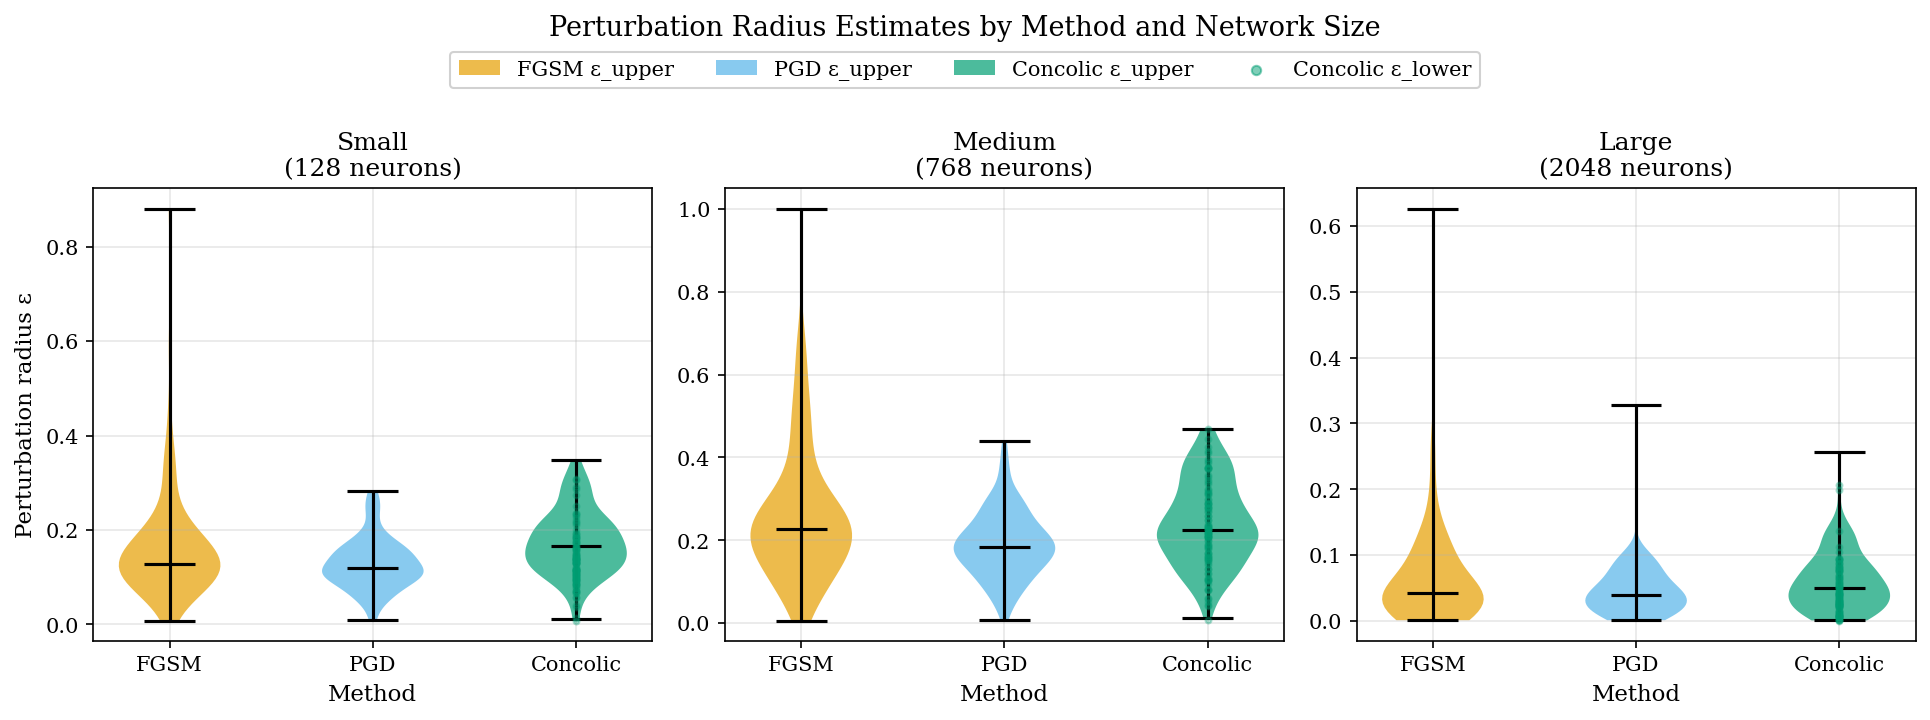

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.5), sharey=False)

for ax, mname in zip(axes, models):
    d    = data[mname]
    sets = [d['fgsm'], d['pgd'], d['concolic_upper']]
    labs = ['FGSM', 'PGD', 'Concolic']
    cols = [COLORS['fgsm'], COLORS['pgd'], COLORS['concolic']]

    vp = ax.violinplot(sets, positions=[1, 2, 3],
                       showmedians=True, showextrema=True)

    for i, (body, col) in enumerate(zip(vp['bodies'], cols)):
        body.set_facecolor(col)
        body.set_alpha(0.7)
    vp['cmedians'].set_color('black')
    vp['cbars'].set_color('black')
    vp['cmins'].set_color('black')
    vp['cmaxes'].set_color('black')

    # overlay concolic lower bound as scatter
    ax.scatter([3] * len(d['concolic_lower']),
               d['concolic_lower'],
               c=COLORS['concolic'], alpha=0.3, s=8,
               label='Concolic ε_lower', zorder=3)

    ax.set_xticks([1, 2, 3])
    ax.set_xticklabels(labs)
    ax.set_title(MODEL_LABELS[mname])
    ax.set_ylabel('Perturbation radius ε' if mname == 'small_mnist' else '')
    ax.set_xlabel('Method')

# shared legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=COLORS['fgsm'],     alpha=0.7, label='FGSM ε_upper'),
    Patch(facecolor=COLORS['pgd'],      alpha=0.7, label='PGD ε_upper'),
    Patch(facecolor=COLORS['concolic'], alpha=0.7, label='Concolic ε_upper'),
    plt.scatter([], [], c=COLORS['concolic'], alpha=0.5, s=20, label='Concolic ε_lower'),
]
fig.legend(handles=legend_elements, loc='upper center',
           ncol=4, bbox_to_anchor=(0.5, 1.02), framealpha=0.9)

fig.suptitle('Perturbation Radius Estimates by Method and Network Size',
             y=1.06, fontsize=13)
plt.tight_layout()
savefig('fig1_bound_distributions')
plt.show()

## 6 — Figure 2: Runtime vs network size (scalability)

  Saved → fig2_scalability.pdf / .png


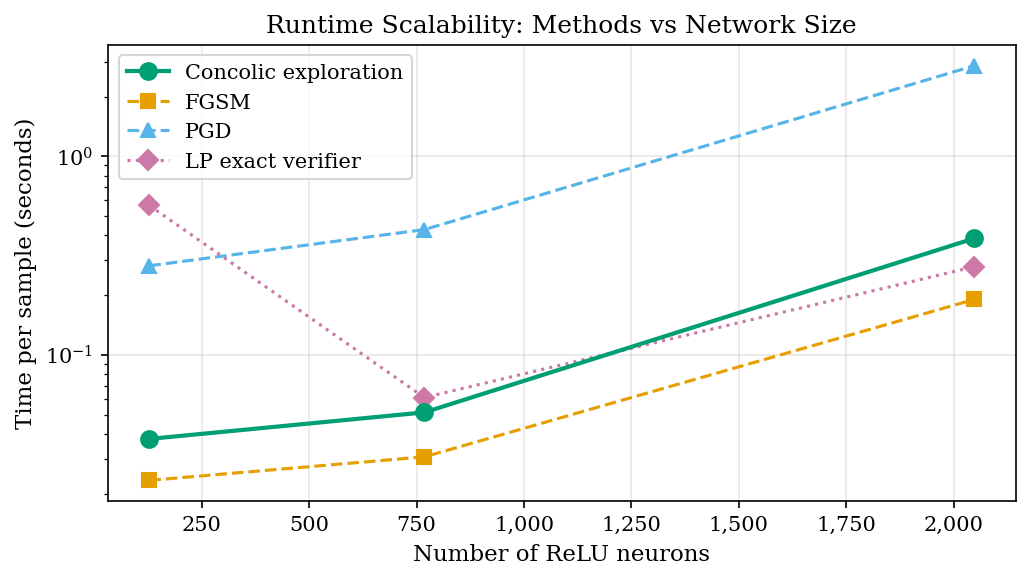

In [7]:
fig, ax = plt.subplots(figsize=(7, 4))

# network sizes
n_neurons = [
    co_small['stats']['n_relu_neurons'],
    co_medium['stats']['n_relu_neurons'],
    co_large['stats']['n_relu_neurons'],
]

# concolic runtimes
concolic_times = [
    co_small['stats']['mean_runtime_sec'],
    co_medium['stats']['mean_runtime_sec'],
    co_large['stats']['mean_runtime_sec'],
]

# fgsm runtimes (fast baseline)
fgsm_times = [
    bl_small['fgsm']['stats']['mean_runtime_sec'],
    bl_medium['fgsm']['stats']['mean_runtime_sec'],
    bl_large['fgsm']['stats']['mean_runtime_sec'],
]

# pgd runtimes
pgd_times = [
    bl_small['pgd']['stats']['mean_runtime_sec'],
    bl_medium['pgd']['stats']['mean_runtime_sec'],
    bl_large['pgd']['stats']['mean_runtime_sec'],
]

# exact verifier times (from scalability results)
exact_times = []
for mname in ['small_mnist', 'medium_mnist', 'large_cifar']:
    if mname in scalability and scalability[mname].get('mean_time_per_call'):
        exact_times.append(scalability[mname]['mean_time_per_call'])
    else:
        exact_times.append(None)

ax.plot(n_neurons, concolic_times, 'o-', color=COLORS['concolic'],
        linewidth=2, markersize=8, label='Concolic exploration', zorder=3)
ax.plot(n_neurons, fgsm_times, 's--', color=COLORS['fgsm'],
        linewidth=1.5, markersize=7, label='FGSM', zorder=2)
ax.plot(n_neurons, pgd_times, '^--', color=COLORS['pgd'],
        linewidth=1.5, markersize=7, label='PGD', zorder=2)

# exact verifier — plot where available
valid_exact_n  = [n for n, t in zip(n_neurons, exact_times) if t is not None]
valid_exact_t  = [t for t in exact_times if t is not None]
if valid_exact_n:
    ax.plot(valid_exact_n, valid_exact_t, 'D:', color=COLORS['exact'],
            linewidth=1.5, markersize=7, label='LP exact verifier')

ax.set_xlabel('Number of ReLU neurons')
ax.set_ylabel('Time per sample (seconds)')
ax.set_title('Runtime Scalability: Methods vs Network Size')
ax.legend()
ax.set_yscale('log')
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
savefig('fig2_scalability')
plt.show()

## 7 — Figure 3: ε_upper vs ε_lower scatter (bound gap)

  Saved → fig3_bound_gap_scatter.pdf / .png


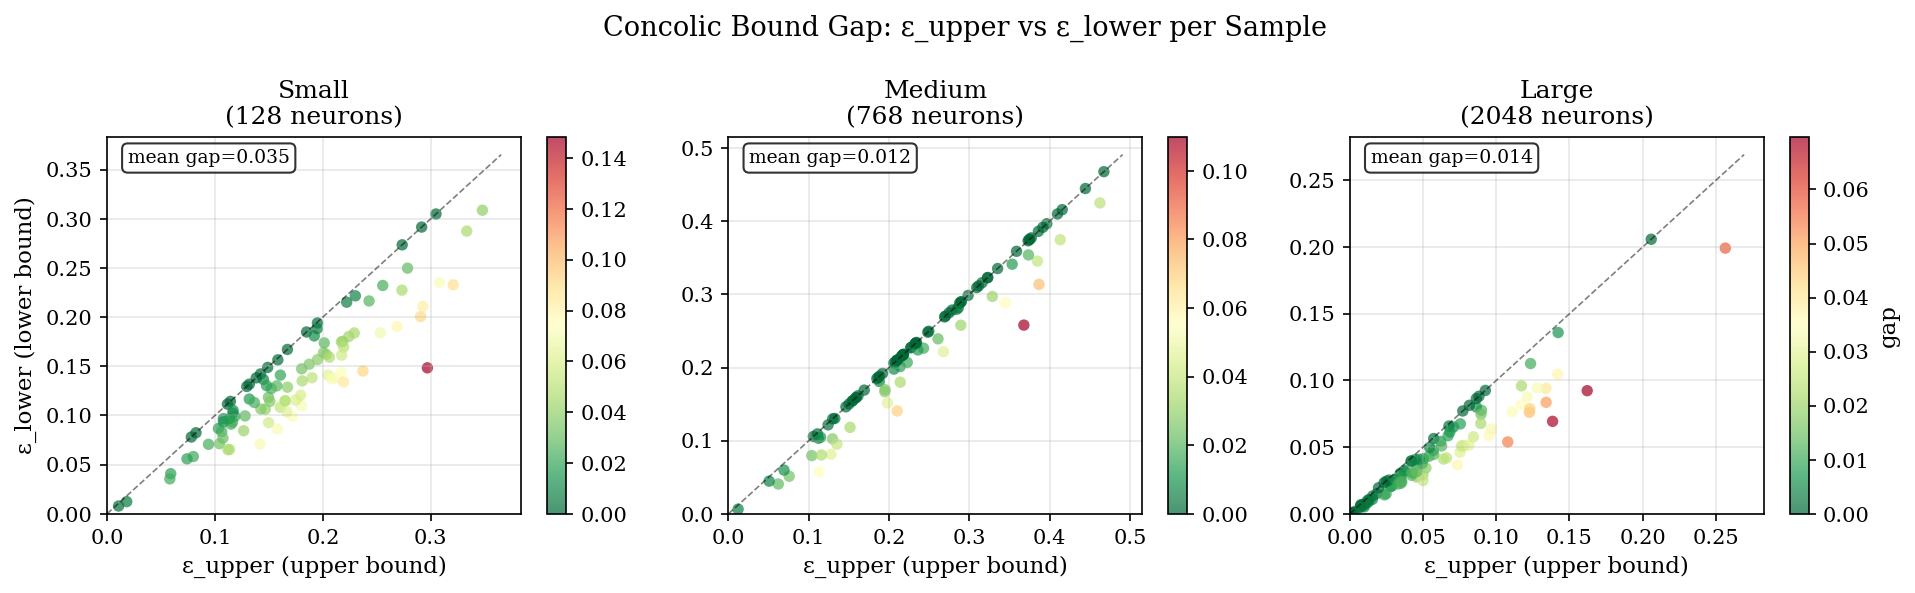

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=False)

for ax, mname in zip(axes, models):
    uppers = data[mname]['concolic_upper']
    lowers = data[mname]['concolic_lower']
    gaps   = uppers - lowers

    sc = ax.scatter(uppers, lowers, c=gaps, cmap='RdYlGn_r',
                    alpha=0.7, s=30, edgecolors='none')

    # diagonal y=x line (perfect bound: gap=0)
    lim = max(uppers.max(), lowers.max()) * 1.05
    ax.plot([0, lim], [0, lim], 'k--', linewidth=0.8, alpha=0.5,
            label='Perfect bound (gap=0)')

    ax.set_xlabel('ε_upper (upper bound)')
    ax.set_ylabel('ε_lower (lower bound)' if mname == 'small_mnist' else '')
    ax.set_title(MODEL_LABELS[mname])
    ax.set_xlim(left=0)
    ax.set_ylim(bottom=0)

    mean_gap = gaps.mean()
    ax.text(0.05, 0.93, f'mean gap={mean_gap:.3f}',
            transform=ax.transAxes, fontsize=9,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    plt.colorbar(sc, ax=ax, label='gap' if mname == 'large_cifar' else '')

fig.suptitle('Concolic Bound Gap: ε_upper vs ε_lower per Sample',
             fontsize=13)
plt.tight_layout()
savefig('fig3_bound_gap_scatter')
plt.show()

## 8 — Figure 4: Heuristic comparison

  Saved → fig4_heuristic_comparison.pdf / .png


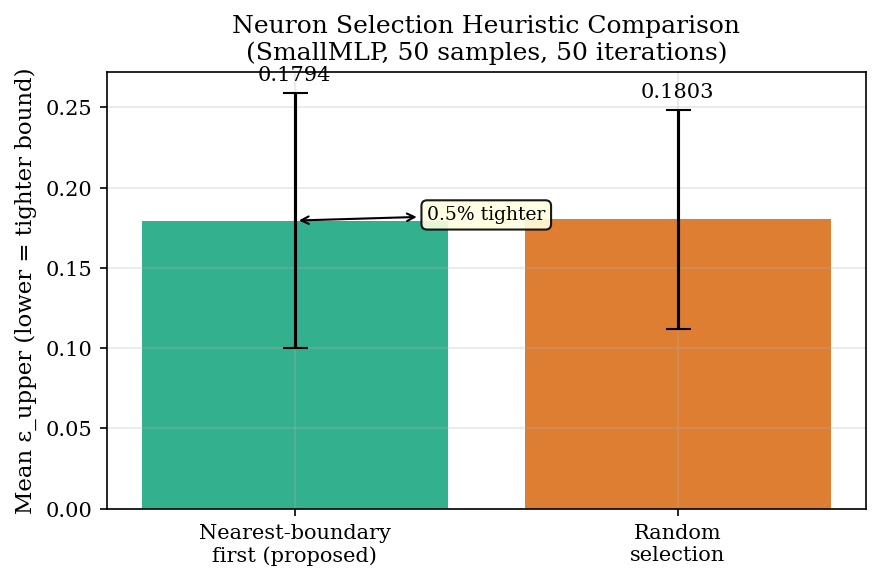

In [9]:
fig, ax = plt.subplots(figsize=(6, 4))

methods   = ['Nearest-boundary\nfirst (proposed)', 'Random\nselection']
means     = [
    heuristic['nearest_boundary_first']['mean_eps_upper'],
    heuristic['random_selection']['mean_eps_upper'],
]
stds      = [
    heuristic['nearest_boundary_first']['std_eps_upper'],
    heuristic['random_selection']['std_eps_upper'],
]
bar_colors = [COLORS['concolic'], '#D55E00']

bars = ax.bar(methods, means, yerr=stds, capsize=6,
              color=bar_colors, alpha=0.8,
              error_kw={'linewidth': 1.5})

# annotate values
for bar, mean, std in zip(bars, means, stds):
    ax.text(bar.get_x() + bar.get_width()/2,
            mean + std + 0.005,
            f'{mean:.4f}',
            ha='center', va='bottom', fontsize=10)

ax.set_ylabel('Mean ε_upper (lower = tighter bound)')
ax.set_title('Neuron Selection Heuristic Comparison\n'
             '(SmallMLP, 50 samples, 50 iterations)')
ax.set_ylim(bottom=0)

# improvement annotation
improvement = (means[1] - means[0]) / means[1] * 100
ax.annotate(f'{improvement:.1f}% tighter',
            xy=(0, means[0]), xytext=(0.5, (means[0]+means[1])/2),
            textcoords='data',
            arrowprops=dict(arrowstyle='<->', color='black'),
            ha='center', fontsize=9,
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9))

plt.tight_layout()
savefig('fig4_heuristic_comparison')
plt.show()

## 9 — Final summary printout

In [10]:
print()
print('═'*70)
print('  EXPERIMENT COMPLETE — ALL OUTPUTS GENERATED')
print('═'*70)
print()
print('  FIGURES:')
for f in sorted(FIGURES_DIR.glob('*.pdf')):
    print(f'    {f.name}')
print()
print('  TABLES:')
for f in sorted(TABLES_DIR.glob('*.json')):
    print(f'    {f.name}')
print()
print('  KEY FINDINGS:')

# concolic vs pgd upper bound comparison on medium model
co_upper = co_medium['stats']['mean_eps_upper']
pgd_upper = bl_medium['pgd']['stats']['mean_eps_upper']
print(f'  1. Concolic ε_upper ({co_upper:.4f}) vs PGD ε_upper ({pgd_upper:.4f}) on MediumMLP')
print(f'     → Concolic is {"tighter" if co_upper < pgd_upper else "looser"} '
      f'by {abs(co_upper - pgd_upper):.4f}')

# lower bound advantage
mean_lower = co_medium['stats']['mean_eps_lower']
print(f'  2. Concolic provides ε_lower = {mean_lower:.4f} (mean) — FGSM/PGD provide 0')

# scalability
time_small  = co_small['stats']['mean_runtime_sec']
time_large  = co_large['stats']['mean_runtime_sec']
time_exact  = scalability.get('large_cifar', {}).get('mean_time_per_call', None)
print(f'  3. Runtime: {time_small:.2f}s (small) → {time_large:.2f}s (large)')
if time_exact:
    print(f'     Exact verifier on large: {time_exact:.2f}s/call '
          f'(~{time_exact*100/60:.0f} min for 100 samples)')

# heuristic
nbf_m   = heuristic['nearest_boundary_first']['mean_eps_upper']
rand_m  = heuristic['random_selection']['mean_eps_upper']
print(f'  4. Nearest-boundary heuristic: {nbf_m:.4f} vs Random: {rand_m:.4f} '
      f'({(rand_m-nbf_m)/rand_m*100:.1f}% improvement)')
print()
print('  All figures saved as PDF (paper-ready) and PNG (preview).')
print('  Integrate into paper using \\includegraphics{results/figures/figN_*.pdf}')


══════════════════════════════════════════════════════════════════════
  EXPERIMENT COMPLETE — ALL OUTPUTS GENERATED
══════════════════════════════════════════════════════════════════════

  FIGURES:
    fig1_bound_distributions.pdf
    fig2_scalability.pdf
    fig3_bound_gap_scatter.pdf
    fig4_heuristic_comparison.pdf

  TABLES:
    table1_comparison.json
    table2_tightness.json

  KEY FINDINGS:
  1. Concolic ε_upper (0.2407) vs PGD ε_upper (0.1917) on MediumMLP
     → Concolic is looser by 0.0490
  2. Concolic provides ε_lower = 0.2291 (mean) — FGSM/PGD provide 0
  3. Runtime: 0.04s (small) → 0.39s (large)
     Exact verifier on large: 0.28s/call (~0 min for 100 samples)
  4. Nearest-boundary heuristic: 0.1794 vs Random: 0.1803 (0.5% improvement)

  All figures saved as PDF (paper-ready) and PNG (preview).
  Integrate into paper using \includegraphics{results/figures/figN_*.pdf}
